In [1]:
from google.colab import drive
drive.mount('/content/drive')   # no-op if already mounted

!cp "/content/drive/MyDrive/new1_16ch_v2_16k_35s.npz" /content/
!ls -lh /content/*.npz

Mounted at /content/drive
-rw------- 1 root root 1.8G Jul  9 13:35 /content/new1_16ch_v2_16k_35s.npz


In [2]:
# ── Imports & global seed ────────────────────────────────────────────────────
import os, re, sys, glob, random
from pathlib import Path
from collections import Counter
from joblib import Parallel, delayed
from scipy.ndimage import zoom as ndimage_zoom

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

import librosa
from tqdm.auto import tqdm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"imports ok  |  torch {torch.__version__}  |  seed {SEED}")

imports ok  |  torch 2.11.0+cu128  |  seed 42


# Sprint 3 — Model Architecture, Training & Evaluation

**Task:** 6-class SER — Angry · Disgusted · Fearful · Happy · Neutral · Sad  
**Dataset:** `uldisvalainis/audio-emotions` (CREMA-D + RAVDESS)

1. **Data** — filter 1–3.5 s · 16-ch features (cached) · 7 active channels · speaker-independent split · standardise · DataLoaders
2. **Model** — 3-block CNN · SpatialDropout2d(0.15) · AdaptiveAvgPool2d(4,4) · `fc_units` varies across ensemble members
3. **Training** — AdamW + warmup + cosine warm restarts · Disgusted-boosted class weights · early stopping with restart grace · 4-model ensemble
4. **Curves** — train/val loss and val accuracy per epoch per member
5. **Evaluation** — test accuracy · per-class F1 · confusion matrix · permutation feature importance
6. **Analysis** — what worked, what didn't, what's next

> Validation used for early stopping and model selection only. Test set touched once in Section 7.

---
## 1 · Environment & constants

In [3]:
# ── Environment & audio constants ────────────────────────────────────────────
ON_KAGGLE = Path("/kaggle/working").exists()
ON_COLAB  = "google.colab" in sys.modules
if not ON_COLAB:
    try:
        import google.colab; ON_COLAB = True
    except ImportError:
        pass

if ON_KAGGLE:
    OUT_DIR = Path("/kaggle/working"); ENV = "Kaggle"
elif ON_COLAB:
    OUT_DIR = Path("/content");       ENV = "Colab"
else:
    OUT_DIR = Path(".");              ENV = "Local"

if ON_KAGGLE:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "librosa"], check=False)

print(f"env={ENV}  out={OUT_DIR}  cuda={torch.cuda.is_available()}", end="")
print(f" | {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "")

SR         = 16000
N_MELS     = 128
HOP        = 512
MAX_LEN    = 110      # ceil(3.5 * 16000 / 512)
CHAN_NAMES = [
    "mel", "delta", "delta2",
    "rms", "f0", "rolloff", "bandwidth", "contrast",
    "mfcc", "mfcc_delta", "flatness", "zcr",
    "centroid", "onset", "tempogram", "voiced_prob",
]

env=Colab  out=/content  cuda=True | Tesla T4


---
## 2 · Data loading

Locate dataset → CREMA-D + RAVDESS only, drop `Suprised` → duration filter 1–3.5 s → 16-channel feature extraction (parallelised, cached) → 12-channel selection → speaker-independent split → per-channel standardisation → GPU-resident DataLoaders.

In [4]:
# ── Locate dataset ───────────────────────────────────────────────────────────
KNOWN_EMOTIONS = {"Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad"}

def find_emotions_dir(root):
    for c in glob.glob(os.path.join(str(root), "**", ""), recursive=True):
        try:
            subs = {d for d in os.listdir(c) if os.path.isdir(os.path.join(c, d))}
        except OSError:
            continue
        if len(KNOWN_EMOTIONS & subs) >= 3:
            return Path(c)
    return None

CANDIDATES = [
    Path("/kaggle/input"),
    Path("/content/Emotions"),
    Path("Emotions"),
    Path("../Emotions"),
    Path.home() / "Downloads" / "Emotions",
]

EMO_DIR = None
for candidate in CANDIDATES:
    if candidate.exists():
        found = find_emotions_dir(candidate)
        if found:
            EMO_DIR = found
            break

if EMO_DIR is None:
    try:
        import kagglehub
        DATA_ROOT = kagglehub.dataset_download("uldisvalainis/audio-emotions")
        EMO_DIR   = find_emotions_dir(Path(DATA_ROOT))
    except Exception as e:
        print("kagglehub failed:", e)

assert EMO_DIR is not None, (
    "Emotions folder not found.\n"
    "Kaggle : attach uldisvalainis/audio-emotions via Add Input.\n"
    "Colab  : set up ~/.kaggle/kaggle.json, then re-run.\n"
    "Local  : place Emotions/<Emotion>/*.wav under the repo root."
)
print("dataset:", EMO_DIR.resolve())

def source_of(name):
    if re.match(r"^\d+-\d+-", name):             return "RAVDESS"
    if re.match(r"^\d{4}_", name):               return "CREMA-D"
    if re.match(r"^(OAF|YAF|OA)_", name):        return "TESS"
    if re.match(r"^[a-z]{1,2}\d+\.wav$", name):  return "SAVEE"
    return "other"

KEEP = {"CREMA-D", "RAVDESS"}

rows = []
for d in sorted(p for p in EMO_DIR.iterdir() if p.is_dir()):
    if d.name == "Suprised":
        continue
    for wav in sorted(d.glob("*.wav")):
        if source_of(wav.name) in KEEP:
            rows.append((str(wav), d.name))

classes      = sorted({emo for _, emo in rows})
class_to_idx = {c: i for i, c in enumerate(classes)}
print(f"{len(classes)} classes:", classes)
print(f"{len(rows)} clips before duration filter")

Using Colab cache for faster access to the 'audio-emotions' dataset.
dataset: /kaggle/input/audio-emotions/Emotions
6 classes: ['Angry', 'Disgusted', 'Fearful', 'Happy', 'Neutral', 'Sad']
9326 clips before duration filter


In [5]:
# ── Duration filter: keep 1.0 s ≤ dur ≤ 3.5 s ──────────────────────────────
all_paths  = [p for p, _ in rows]
all_labels = [e for _, e in rows]

durations = [librosa.get_duration(path=p) for p in tqdm(all_paths, desc="duration scan")]

filtered = [(p, e) for p, e, d in zip(all_paths, all_labels, durations) if 1.0 <= d <= 3.5]
n_before, n_after = len(rows), len(filtered)
print(f"removed {n_before - n_after} clips  ({n_before} -> {n_after} remain)")

paths  = [p for p, _ in filtered]
labels = [class_to_idx[e] for _, e in filtered]

dist = Counter(e for _, e in filtered)
for emo in sorted(dist):
    print(f"  {emo}: {dist[emo]}")

duration scan:   0%|          | 0/9326 [00:00<?, ?it/s]

removed 1983 clips  (9326 -> 7343 remain)
  Angry: 1236
  Disgusted: 1136
  Fearful: 1307
  Happy: 1313
  Neutral: 1112
  Sad: 1239


In [6]:
# ── 16-channel feature extraction (parallelised, cached) ─────────────────────
# Output per clip: (16, 128, 110)
# f0/centroid/rolloff/bandwidth masked to voiced frames (voiced_prob > 0.5)
# f0 converted to semitones vs clip median — removes speaker pitch baseline
N_JOBS = min(4, os.cpu_count() or 2)
print(f"Using {N_JOBS} CPU cores")

def _fit_2d(arr, max_len=MAX_LEN):
    if arr.shape[1] < max_len:
        return np.pad(arr, ((0, 0), (0, max_len - arr.shape[1])))
    return arr[:, :max_len]

def _tile_1d(arr, height=N_MELS, max_len=MAX_LEN):
    arr = arr[:max_len] if len(arr) >= max_len else np.pad(arr, (0, max_len - len(arr)))
    return np.tile(arr, (height, 1))

def _resize_freq(arr, target=N_MELS):
    if arr.shape[0] == target:
        return arr
    return ndimage_zoom(arr, (target / arr.shape[0], 1), order=1)

def extract_features(path):
    y, sr = librosa.load(path, sr=SR)

    mel_power = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=2048, hop_length=HOP)
    mel_db    = librosa.power_to_db(mel_power, ref=np.max)
    delta     = librosa.feature.delta(mel_db)
    delta2    = librosa.feature.delta(mel_db, order=2)

    rms                = librosa.feature.rms(y=y, hop_length=HOP)[0]
    f0, _, voiced_prob = librosa.pyin(y, fmin=librosa.note_to_hz("C2"),
                                      fmax=librosa.note_to_hz("C7"), sr=sr, hop_length=HOP)
    f0          = np.nan_to_num(f0, nan=0.0)
    voiced_prob = np.nan_to_num(voiced_prob, nan=0.0)
    voiced_mask = (voiced_prob > 0.5).astype("float32")

    voiced_f0 = f0[voiced_mask > 0]; voiced_f0 = voiced_f0[voiced_f0 > 0]
    if len(voiced_f0) > 0:
        f0_median    = np.median(voiced_f0)
        f0_semitones = np.where(f0 > 0, 12.0 * np.log2((f0 + 1e-8) / (f0_median + 1e-8)), 0.0).astype("float32")
    else:
        f0_semitones = np.zeros_like(f0)
    f0_semitones *= voiced_mask

    rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, hop_length=HOP)[0]
    contrast  = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP)
    mfcc      = librosa.feature.mfcc(S=mel_db, n_mfcc=13)  # reuses mel_db
    mfcc_delta = librosa.feature.delta(mfcc)
    flatness  = librosa.feature.spectral_flatness(y=y, hop_length=HOP)[0]
    zcr       = librosa.feature.zero_crossing_rate(y, hop_length=HOP)[0]
    centroid  = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP)[0] * voiced_mask
    rolloff   = rolloff   * voiced_mask
    bandwidth = bandwidth * voiced_mask
    onset      = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP)
    tempo_gram = librosa.feature.tempogram(y=y, sr=sr, hop_length=HOP)

    return np.stack([
        _fit_2d(mel_db), _fit_2d(delta), _fit_2d(delta2),
        _tile_1d(rms), _tile_1d(f0_semitones), _tile_1d(rolloff), _tile_1d(bandwidth),
        _resize_freq(_fit_2d(contrast)),
        _resize_freq(_fit_2d(mfcc)), _resize_freq(_fit_2d(mfcc_delta)),
        _tile_1d(flatness), _tile_1d(zcr), _tile_1d(centroid), _tile_1d(onset),
        _resize_freq(_fit_2d(tempo_gram)), _tile_1d(voiced_prob),
    ], axis=0).astype("float32")

CACHE = OUT_DIR / "new1_16ch_v2_16k_35s.npz"
if CACHE.exists():
    dat = np.load(str(CACHE), allow_pickle=True)
    X, y_arr, cached_classes = dat["X"], dat["y"], list(dat["classes"])
    assert list(cached_classes) == classes, f"cache class mismatch — delete {CACHE} and re-run"
    print("loaded cached features:", X.shape)
else:
    print("warming up numba JIT...")
    librosa.pyin(np.zeros(SR, dtype="float32"), fmin=librosa.note_to_hz("C2"),
                 fmax=librosa.note_to_hz("C7"), sr=SR)
    print("warmup done — extracting")
    results = Parallel(n_jobs=N_JOBS, verbose=5)(delayed(extract_features)(p) for p in paths)
    X     = np.stack(results).astype("float32")
    y_arr = np.array(labels, dtype="int64")
    np.savez_compressed(str(CACHE), X=X, y=y_arr, classes=np.array(classes))
    print("extracted + cached:", X.shape)

print("X :", X.shape, "  y :", y_arr.shape)
print("channels:", CHAN_NAMES)

Using 4 CPU cores
loaded cached features: (7343, 16, 128, 110)
X : (7343, 16, 128, 110)   y : (7343,)
channels: ['mel', 'delta', 'delta2', 'rms', 'f0', 'rolloff', 'bandwidth', 'contrast', 'mfcc', 'mfcc_delta', 'flatness', 'zcr', 'centroid', 'onset', 'tempogram', 'voiced_prob']


### 2.1 · Channel selection

All 16 channels are extracted and cached. The cell below selects the **7 active channels** fed to the model.

**Disabled (9 channels):**
- `mfcc` — encodes speaker identity (linear transform of mel)
- `flatness`, `zcr`, `tempogram`, `voiced_prob` — near-zero permutation importance
- `f0`, `rolloff`, `bandwidth`, `centroid` — voiced-masked versions too sparse on speaker-independent split; permutation importance ≤ +0.013 or negative

In [7]:
# === Feature selection — toggle channels to explore combinations ===
# All 16 channels are always extracted and cached above.
# Set True/False here — no re-extraction needed, just rerun from this cell.
#
# Index: 0=mel  1=delta  2=delta2  3=rms  4=f0  5=rolloff
#        6=bandwidth  7=contrast  8=mfcc  9=mfcc_delta  10=flatness  11=zcr
#        12=centroid  13=onset  14=tempogram  15=voiced_prob

USE = {
    "mel":        True,   # overall spectral shape — captures timbre and vowel quality
    "delta":      True,   # rate of spectral change — captures dynamic expression
    "delta2":     True,   # acceleration of spectral change — captures abrupt emotional shifts
    "rms":        True,   # energy / loudness — high in angry/happy, low in sad/neutral
    "f0":         False,  # voiced-masked semitones too sparse on speaker-independent split — permutation importance -0.002
    "rolloff":    False,  # permutation importance near-zero (+0.007) — drop
    "bandwidth":  False,  # permutation importance near-zero (+0.013) — drop
    "contrast":   True,   # peak-to-valley difference across sub-bands — voice vs noise ratio
    "mfcc":       False,  # vocal tract shape (formants) — encodes speaker identity
    "mfcc_delta": True,   # rate of vocal tract change — articulation speed
    "flatness":   False,  # noise-likeness — low importance in pilot runs
    "zcr":        False,  # rate of sign changes — correlated with mel in this corpus
    "centroid":   False,  # permutation importance near-zero (+0.001) — drop
    "onset":      True,   # energy flux / attack rate — fast onsets in angry, slow in sad
    "tempogram":  False,  # local tempo autocorrelation — permutation importance near-zero (+0.016)
    "voiced_prob": False, # voicing probability — low permutation importance (+0.036), redundant with f0
}

sel_idx    = [i for i, n in enumerate(CHAN_NAMES) if USE[n]]
sel_names  = [CHAN_NAMES[i] for i in sel_idx]
N_CHAN_SEL = len(sel_idx)
X_sel      = X[:, sel_idx, :, :]

print(f"Selected {N_CHAN_SEL} channels : {sel_names}")
print(f"X_sel shape               : {X_sel.shape}")

Selected 7 channels : ['mel', 'delta', 'delta2', 'rms', 'contrast', 'mfcc_delta', 'onset']
X_sel shape               : (7343, 7, 128, 110)


### 2.2 · Speaker-independent split + DataLoaders

Three disjoint **speaker** groups (not just clips) — same actor cannot appear in both train and test:

| Split | Speakers | Purpose |
|-------|----------|---------|
| Train | ~68% | gradient updates |
| Validation | ~12% (15% of non-test) | early stopping, model selection |
| Test | 20% | final evaluation, touched once in Section 7 |

Per-channel standardisation uses **train statistics only**. Tensors are pre-loaded to GPU so batches require no host-to-device copy.

In [8]:
# ── Speaker-independent train / val / test split + standardisation ────────────
def speaker_id(path):
    name = Path(path).name
    if re.match(r"^\d{4}_", name):   return "CREMA_" + name[:4]
    if re.match(r"^\d+-\d+-", name): return "RAVDESS_" + name.replace(".wav", "").split("-")[-1]
    return "other_" + name

clip_speakers   = [speaker_id(p) for p in paths]
unique_speakers = np.array(sorted(set(clip_speakers)))

rng_spk = np.random.default_rng(SEED)
rng_spk.shuffle(unique_speakers)
n_test_spk    = max(1, int(0.20 * len(unique_speakers)))
test_speakers = set(unique_speakers[:n_test_spk])
remaining     = unique_speakers[n_test_spk:]
n_val_spk     = max(1, int(0.15 * len(remaining)))
val_speakers  = set(remaining[:n_val_spk])

train_idx = [i for i, s in enumerate(clip_speakers) if s not in test_speakers and s not in val_speakers]
val_idx   = [i for i, s in enumerate(clip_speakers) if s in val_speakers]
test_idx  = [i for i, s in enumerate(clip_speakers) if s in test_speakers]

Xtr, ytr = X_sel[train_idx], y_arr[train_idx]
Xva, yva = X_sel[val_idx],   y_arr[val_idx]
Xte, yte = X_sel[test_idx],  y_arr[test_idx]

mu = Xtr.mean(axis=(0, 2, 3), keepdims=True)
sd = Xtr.std(axis=(0, 2, 3), keepdims=True)
Xtr = (Xtr - mu) / (sd + 1e-9)
Xva = (Xva - mu) / (sd + 1e-9)
Xte = (Xte - mu) / (sd + 1e-9)


def spec_augment(x, T_max=20, F_max=20):
    """SpecAugment: one random time mask + one random freq mask on a (C, F, T) tensor."""
    x = x.clone()
    C, F, T = x.shape
    t  = int(torch.randint(1, T_max + 1, (1,)))
    t0 = int(torch.randint(0, T - t + 1, (1,)))
    x[:, :, t0:t0 + t] = 0.0
    f  = int(torch.randint(1, F_max + 1, (1,)))
    f0 = int(torch.randint(0, F - f + 1, (1,)))
    x[:, f0:f0 + f, :] = 0.0
    return x


class AudioDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X       = torch.as_tensor(X, dtype=torch.float32)
        self.y       = torch.as_tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):  return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            x = spec_augment(x)
        return x, self.y[idx]


print(f"Speakers : {len(unique_speakers)} total  ->  "
      f"train {len(unique_speakers) - n_test_spk - n_val_spk}  val {n_val_spk}  test {n_test_spk}")
print(f"Clips    : train {len(Xtr)}  val {len(Xva)}  test {len(Xte)}")

idx_to_class = {v: k for k, v in class_to_idx.items()}
tr_dist = Counter(idx_to_class[l] for l in ytr.tolist())
va_dist = Counter(idx_to_class[l] for l in yva.tolist())
te_dist = Counter(idx_to_class[l] for l in yte.tolist())
print(f"\n  {'':12s}  {'train':>6}  {'val':>6}  {'test':>6}")
for emo in sorted(tr_dist):
    print(f"  {emo:12s}  {tr_dist[emo]:6d}  {va_dist.get(emo,0):6d}  {te_dist.get(emo,0):6d}")

Speakers : 112 total  ->  train 77  val 13  test 22
Clips    : train 4998  val 875  test 1470

                 train     val    test
  Angry            833     152     251
  Disgusted        784     128     224
  Fearful          891     156     260
  Happy            892     163     258
  Neutral          754     133     225
  Sad              844     143     252


In [9]:
# ── DataLoaders (GPU-resident tensors → zero copy per batch) ─────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256

Xtr_gpu = torch.from_numpy(Xtr).to(device);  ytr_gpu = torch.from_numpy(ytr).to(device)
Xva_gpu = torch.from_numpy(Xva).to(device);  yva_gpu = torch.from_numpy(yva).to(device)
Xte_gpu = torch.from_numpy(Xte).to(device);  yte_gpu = torch.from_numpy(yte).to(device)

# augment=True on train only — val/test always get clean spectrograms
train_ds = AudioDataset(Xtr_gpu, ytr_gpu, augment=False)
val_ds   = AudioDataset(Xva_gpu, yva_gpu)
test_ds  = AudioDataset(Xte_gpu, yte_gpu)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"device        : {device}")
print(f"batch tensor  : {tuple(xb.shape)}  ({xb.dtype}, on {xb.device})")
print(f"batches/epoch : train {len(train_loader)}  val {len(val_loader)}  test {len(test_loader)}")
print(f"SpecAugment   : disabled (dataset too small for masking)")
if device == "cuda":
    print(f"GPU RAM used  : {torch.cuda.memory_allocated()/1e9:.2f} GB")

device        : cuda
batch tensor  : (256, 7, 128, 110)  (torch.float32, on cuda:0)
batches/epoch : train 20  val 4  test 6
SpecAugment   : disabled (dataset too small for masking)
GPU RAM used  : 3.00 GB


---
## 3 · Model architecture

`MultiChannelCNN` — 3-block CNN with adaptive pooling and a parameterised FC head.

| Component | Choice | Justification |
|-----------|--------|---------------|
| Conv blocks | 3 blocks (n_ch → 32 → 64 → 128) | Sufficient depth for spectro-temporal patterns without overfitting ~5.8k clips. |
| Kernel | 3×3, same padding | Captures frequency and time patterns equally. |
| SpatialDropout2d(0.15) | per block | Drops entire feature maps — stronger regulariser than pixel dropout. |
| AdaptiveAvgPool2d(4, 4) | after block 3 | Fixed 2048-dim vector regardless of input size. |
| FC head | Linear(2048 → fc_units → 6) + Dropout(0.4) | `fc_units` varied across ensemble members (128/256) for diversity. |

In [10]:
# ── MultiChannelCNN: 3-block CNN with SpatialDropout2d + AdaptiveAvgPool2d ────
class MultiChannelCNN(nn.Module):
    def __init__(self, n_channels, num_classes=6, fc_units=128):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(n_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.15))
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.15))
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.15))
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4, fc_units), nn.ReLU(),
            nn.Dropout(0.4), nn.Linear(fc_units, num_classes))

    def forward(self, x):
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        x = self.pool(x)
        return self.fc(x.flatten(1))


n_params_128 = sum(p.numel() for p in MultiChannelCNN(n_channels=N_CHAN_SEL, fc_units=128).parameters() if p.requires_grad)
n_params_256 = sum(p.numel() for p in MultiChannelCNN(n_channels=N_CHAN_SEL, fc_units=256).parameters() if p.requires_grad)
print(f"device   : {device}")
print(f"channels : {sel_names}")
print(f"trainable params — fc=128 : {n_params_128:,}")
print(f"trainable params — fc=256 : {n_params_256:,}")

device   : cuda
channels : ['mel', 'delta', 'delta2', 'rms', 'contrast', 'mfcc_delta', 'onset']
trainable params — fc=128 : 357,894
trainable params — fc=256 : 620,934


---
## 4 · Hyperparameters

| Hyperparameter | Value | Justification |
|----------------|-------|---------------|
| Batch size | 256 | Fills T4 VRAM with GPU-resident dataset; stabilises BatchNorm. |
| LR (peak) | 4e-4 | 3e-4 converged too slowly; 5e-4 destabilised seed=7 models. |
| Optimizer | AdamW, weight_decay=1e-2 | Decoupled weight decay prevents LR/WD coupling. |
| LR schedule | Linear warmup (10 ep) → CosineAnnealingWarmRestarts (T_0=110) | Warmup prevents early divergence; warm restart at ep120 lets model escape local minima. Early-stop counter resets at each restart so the LR kick doesn't trigger premature stopping. |
| Max epochs | 230 | Covers exactly 2 full cosine cycles (10 + 110 + 110). A third partial cycle caused disruption. |
| Loss | CrossEntropy + balanced class weights + label smoothing 0.10 | Class weights counter imbalance; 1.5× boost for Disgusted. Label smoothing 0.10 reduced train/val gap. Focal loss tried and hurt. |
| Gradient clip | max-norm 1.0 | Prevents loss spikes under AMP. |
| Early stopping | patience 50, grace 40, 3-epoch smoothed val acc | Grace period covers warmup + restart disruption. Smoothing avoids single noisy epochs triggering stops. |
| Ensemble | A: fc=128, s42 · B: fc=256, s42 · C: fc=128, s7 · D: fc=128, s123 | Diversity from head width and seed. D uses fc=128 — fc=256+seed=7 was LR-restart-unstable. |
| Mixed precision | AMP bf16 + GradScaler | ~2× faster on T4. |

In [11]:
# === Hyperparameters — defined and frozen before the training loop ===
HP = dict(
    batch_size      = BATCH_SIZE,
    lr_peak         = 4e-4,    # 3e-4 too slow, 5e-4 hurt seed=7 — compromise
    lr_min          = 1e-5,
    weight_decay    = 1e-2,
    warmup_epochs   = 10,
    max_epochs      = 230,     # stop cleanly after 2 full cycles (10 warmup + 110×2)
    t_restart       = 110,     # restart at ep120, second cycle completes by ep230
    label_smoothing = 0.10,         # raised from 0.05 — cuts train/val gap
    clip_grad_norm  = 1.0,
    es_patience     = 50,
    es_grace        = 40,
    es_smooth_k     = 3,
    seed_global     = SEED,
    ensemble        = [
        dict(fc_units=128, seed=42, label="A fc128 s42"),
        dict(fc_units=256, seed=42, label="B fc256 s42"),
        dict(fc_units=128, seed=7,  label="C fc128 s7"),
        dict(fc_units=128, seed=123, label="D fc128 s123"),
    ],
)
for k, v in HP.items():
    print(f"{k:16s}: {v}")

batch_size      : 256
lr_peak         : 0.0004
lr_min          : 1e-05
weight_decay    : 0.01
warmup_epochs   : 10
max_epochs      : 230
t_restart       : 110
label_smoothing : 0.1
clip_grad_norm  : 1.0
es_patience     : 50
es_grace        : 40
es_smooth_k     : 3
seed_global     : 42
ensemble        : [{'fc_units': 128, 'seed': 42, 'label': 'A fc128 s42'}, {'fc_units': 256, 'seed': 42, 'label': 'B fc256 s42'}, {'fc_units': 128, 'seed': 7, 'label': 'C fc128 s7'}, {'fc_units': 128, 'seed': 123, 'label': 'D fc128 s123'}]


---
## 5 · Training

`train_model` trains one ensemble member end-to-end, logging train loss, val loss, val accuracy, and LR per epoch. All checkpointing and early stopping use the **validation** set only — test set untouched until Section 7.

In [12]:
# ── Training loop: warmup + cosine warm restarts, AMP, val-based early stopping ──
USE_AMP = (device == "cuda")

def evaluate(model, loader, criterion):
    model.eval()
    lsum = correct = total = 0
    with torch.no_grad(), torch.amp.autocast("cuda", enabled=USE_AMP):
        for xb, yb in loader:
            out   = model(xb)
            loss  = criterion(out, yb)
            lsum    += loss.item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += len(yb)
    return lsum / total, correct / total


def train_model(fc_units, seed, label=""):
    torch.manual_seed(seed)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    m = MultiChannelCNN(n_channels=N_CHAN_SEL, num_classes=len(classes),
                        fc_units=fc_units).to(device)

    cw = compute_class_weight("balanced", classes=np.arange(len(classes)), y=ytr)
    cw[classes.index("Disgusted")] *= 1.5
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device),
        label_smoothing=HP["label_smoothing"],
    )
    optimizer = torch.optim.AdamW(m.parameters(), lr=HP["lr_peak"],
                                  weight_decay=HP["weight_decay"])

    # 10-epoch linear warmup, then cosine warm restarts every t_restart epochs
    warmup = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1/30, end_factor=1.0,
        total_iters=HP["warmup_epochs"])
    cosine = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=HP["t_restart"], T_mult=1, eta_min=HP["lr_min"])
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup, cosine],
        milestones=[HP["warmup_epochs"]])

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "lr":         [],
    }
    best_acc    = 0.0
    best_state  = None
    best_epoch  = 0
    best_smooth = -float("inf")
    no_improve  = 0
    recent_accs = []

    for epoch in range(1, HP["max_epochs"] + 1):
        cur_lr = optimizer.param_groups[0]["lr"]

        m.train()
        lsum = total = correct = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                out  = m(xb)
                loss = criterion(out, yb)
            pred = out.argmax(dim=1)
            correct += (pred == yb).sum().item()
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(m.parameters(), HP["clip_grad_norm"])
            scaler.step(optimizer)
            scaler.update()
            lsum  += loss.item() * len(yb)
            total += len(yb)
        train_loss = lsum / total
        train_acc  = correct / total

        val_loss, val_acc = evaluate(m, val_loader, criterion)
        scheduler.step()

        # reset early-stop counter at warm restart so the LR kick doesn't trigger premature stop
        if epoch == HP["warmup_epochs"] + HP["t_restart"]:
            no_improve = 0
            best_smooth = -float("inf")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(cur_lr)

        recent_accs.append(val_acc)
        smooth_acc = float(np.mean(recent_accs[-HP["es_smooth_k"]:]))

        if val_acc > best_acc:
            best_acc, best_epoch = val_acc, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

        if epoch > HP["es_grace"]:
            if smooth_acc > best_smooth + 1e-4:
                best_smooth = smooth_acc
                no_improve  = 0
            else:
                no_improve += 1

        if epoch % 25 == 0 or epoch == 1:
            print(f"  [{label}] epoch {epoch:3d}  "
                  f"train {train_loss:.3f}/{train_acc:.3f}  "
                  f"val {val_loss:.3f}/{val_acc:.3f}  "
                  f"smooth {smooth_acc:.3f}  lr={cur_lr:.2e}")

        if epoch > HP["es_grace"] and no_improve >= HP["es_patience"]:
            print(f"  [{label}] early stop ep {epoch}  best val_acc={best_acc:.3f} (ep {best_epoch})")
            break

    m.load_state_dict(best_state)
    print(f"  [{label}] best val_acc {best_acc:.3f} at epoch {best_epoch}\n")
    return m, best_acc, best_epoch, history


models, histories, val_accs, best_epochs = [], [], [], []
for cfg in HP["ensemble"]:
    print(f"=== Training Model {cfg['label']} ===")
    m, acc, ep, hist = train_model(cfg["fc_units"], cfg["seed"], cfg["label"])
    models.append(m); histories.append(hist)
    val_accs.append(acc); best_epochs.append(ep)

print("Validation accuracy — " + "  ".join(
    f"{cfg['label']}: {a:.3f}" for cfg, a in zip(HP["ensemble"], val_accs)))

=== Training Model A fc128 s42 ===
  [A fc128 s42] epoch   1  train 1.817/0.170  val 1.781/0.243  smooth 0.243  lr=1.33e-05
  [A fc128 s42] epoch  25  train 1.359/0.516  val 1.413/0.469  smooth 0.453  lr=3.85e-04
  [A fc128 s42] epoch  50  train 1.229/0.589  val 1.385/0.498  smooth 0.502  lr=2.91e-04
  [A fc128 s42] epoch  75  train 1.152/0.633  val 1.376/0.514  smooth 0.526  lr=1.55e-04
  [A fc128 s42] epoch 100  train 1.089/0.672  val 1.354/0.537  smooth 0.539  lr=4.40e-05
  [A fc128 s42] epoch 125  train 1.133/0.641  val 1.346/0.529  smooth 0.534  lr=3.99e-04
  [A fc128 s42] epoch 150  train 1.025/0.706  val 1.322/0.579  smooth 0.560  lr=3.37e-04
  [A fc128 s42] epoch 175  train 0.934/0.753  val 1.443/0.507  smooth 0.542  lr=2.11e-04
  [A fc128 s42] epoch 200  train 0.890/0.780  val 1.343/0.567  smooth 0.562  lr=8.16e-05
  [A fc128 s42] early stop ep 222  best val_acc=0.582 (ep 171)
  [A fc128 s42] best val_acc 0.582 at epoch 171

=== Training Model B fc256 s42 ===
  [B fc256 s42] e

---
## 6 · Loss curves

Train/val loss per epoch for each ensemble member. Dashed line = best checkpoint epoch; shaded band = warmup phase.

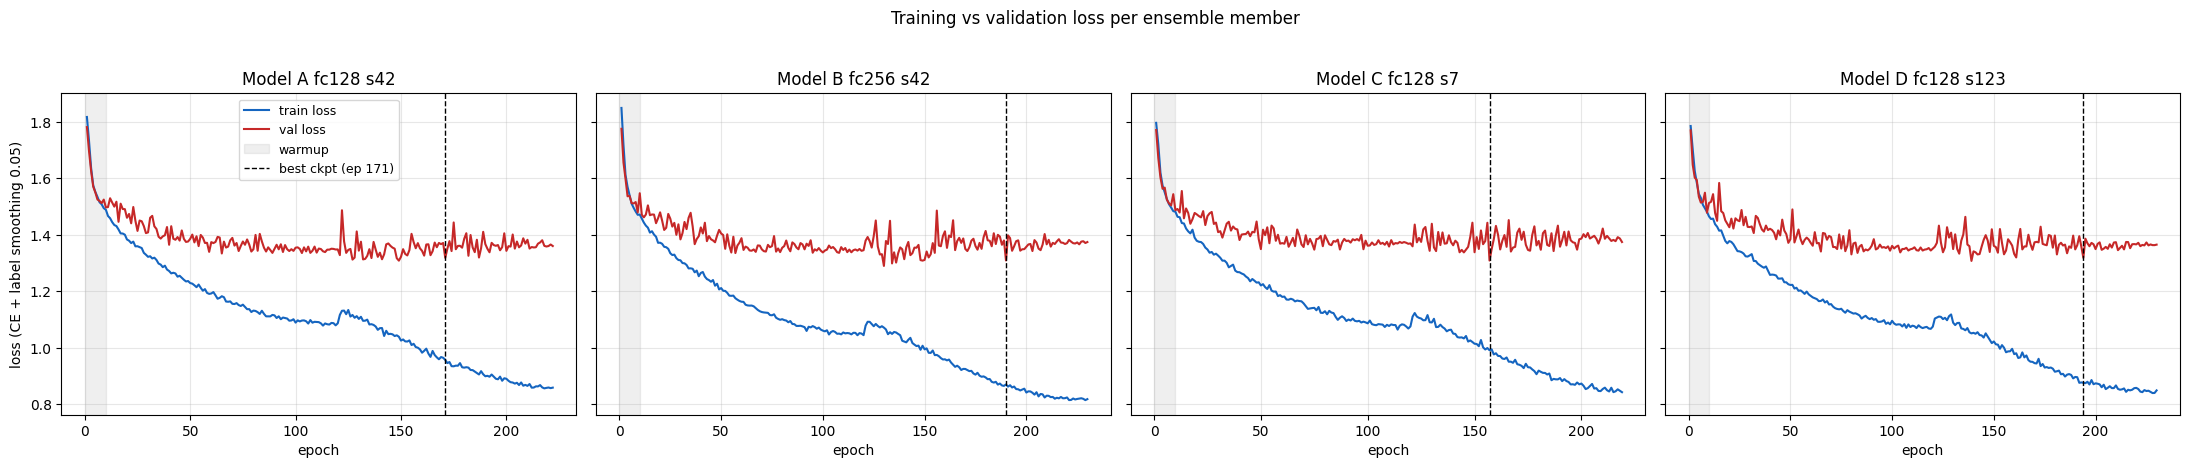

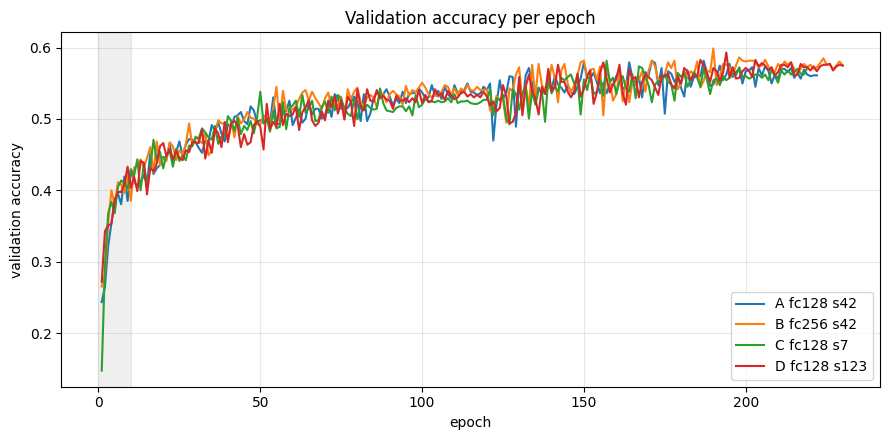

In [13]:
# ── Loss curves for all ensemble members ──────────────────────────────────────
labels_ = [cfg["label"] for cfg in HP["ensemble"]]
n_m     = len(HP["ensemble"])

fig, axes = plt.subplots(1, n_m, figsize=(5.5 * n_m, 4.5), sharey=True)
if n_m == 1: axes = [axes]
for ax, hist, lab, be in zip(axes, histories, labels_, best_epochs):
    ep = np.arange(1, len(hist["train_loss"]) + 1)
    ax.plot(ep, hist["train_loss"], label="train loss", color="#1565C0")
    ax.plot(ep, hist["val_loss"],   label="val loss",   color="#C62828")
    ax.axvspan(0, HP["warmup_epochs"], color="grey", alpha=0.12, label="warmup")
    ax.axvline(be, color="black", ls="--", lw=1, label=f"best ckpt (ep {be})")
    ax.set_title(f"Model {lab}")
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("loss (CE + label smoothing 0.05)")
axes[0].legend(fontsize=9)
fig.suptitle("Training vs validation loss per ensemble member", y=1.03)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
for hist, lab in zip(histories, labels_):
    ep = np.arange(1, len(hist["val_acc"]) + 1)
    ax.plot(ep, hist["val_acc"], label=f"{lab}")
ax.axvspan(0, HP["warmup_epochs"], color="grey", alpha=0.12)
ax.set_xlabel("epoch"); ax.set_ylabel("validation accuracy")
ax.set_title("Validation accuracy per epoch")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

### 6.1 · What the curves reveal

- **Warmup works as intended** — both losses fall steeply in the first 10 epochs with no spikes.
- **Non-zero loss floor** — label smoothing 0.10 prevents cross-entropy reaching zero even with a perfect classifier.
- **Warm restart disruption at ep120** — val accuracy dips for ~20 epochs after the LR kicks back to peak, then recovers. Best checkpoints typically appear 40–70 epochs into the second cycle. The early-stop counter resets at ep120 so this dip doesn't trigger premature stopping.
- **Noisy val curves** — the validation set covers ~12% of speakers; accuracy jumps 1–2 pts per epoch on speaker-driven noise. A 3-epoch smoothed accuracy drives early stopping while raw best drives checkpointing.
- **Persistent train/val gap** — by ep200 the gap is ~0.22. SpatialDropout2d and label smoothing limit it, but the speaker-independent split means test speakers are genuinely unseen, keeping a floor on the gap.

---
## 7 · Evaluation on the held-out test set

Test set (20% of speakers, never seen during training or model selection) evaluated once. Ensemble prediction = mean of four models' softmax distributions.

In [14]:
# ── Final evaluation: ensemble softmax averaging on the test set ──────────────
for m in models:
    m.eval()

all_probs = {i: [] for i in range(len(models))}
all_gt    = []
with torch.no_grad(), torch.amp.autocast("cuda", enabled=USE_AMP):
    for xb, yb in test_loader:
        for i, m in enumerate(models):
            all_probs[i].append(torch.softmax(m(xb).float(), dim=1).cpu().numpy())
        all_gt.append(yb.cpu().numpy())

all_gt     = np.concatenate(all_gt)
probs_each = [np.concatenate(all_probs[i]) for i in range(len(models))]
probs_ens  = np.mean(probs_each, axis=0)
preds_ens  = probs_ens.argmax(1)

print("Test accuracy — individual models:")
for cfg, pr in zip(HP["ensemble"], probs_each):
    print(f"  {cfg['label']:12s}: {accuracy_score(all_gt, pr.argmax(1)):.3f}")
ens_acc = accuracy_score(all_gt, preds_ens)
print(f"\nTest accuracy — ensemble : {ens_acc:.3f}\n")

print(classification_report(all_gt, preds_ens, target_names=classes, digits=3))

for avg in ("macro", "weighted"):
    p, r, f1, _ = precision_recall_fscore_support(all_gt, preds_ens, average=avg)
    print(f"{avg:8s} avg — precision {p:.3f}  recall {r:.3f}  F1 {f1:.3f}")

Test accuracy — individual models:
  A fc128 s42 : 0.620
  B fc256 s42 : 0.612
  C fc128 s7  : 0.620
  D fc128 s123: 0.618

Test accuracy — ensemble : 0.629

              precision    recall  f1-score   support

       Angry      0.809     0.777     0.793       251
   Disgusted      0.528     0.589     0.557       224
     Fearful      0.597     0.508     0.549       260
       Happy      0.648     0.585     0.615       258
     Neutral      0.654     0.707     0.679       225
         Sad      0.553     0.619     0.584       252

    accuracy                          0.629      1470
   macro avg      0.632     0.631     0.630      1470
weighted avg      0.633     0.629     0.629      1470

macro    avg — precision 0.632  recall 0.631  F1 0.630
weighted avg — precision 0.633  recall 0.629  F1 0.629


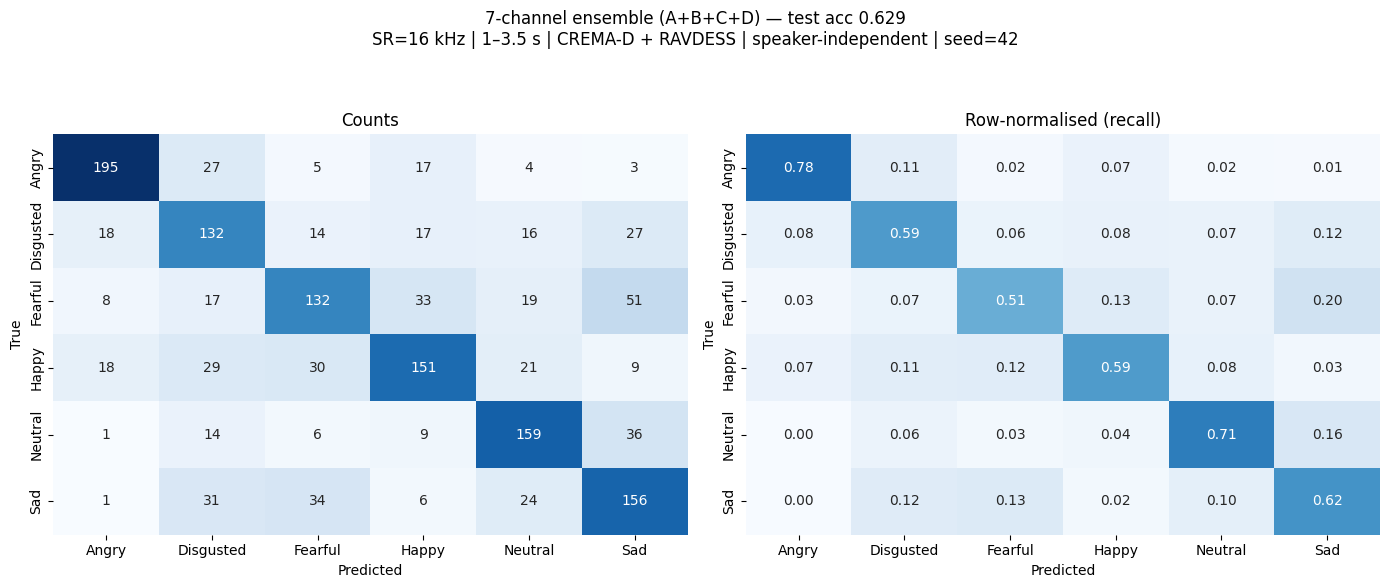

model saved -> /content/sprint3_model.pt


In [15]:
# ── Confusion matrix: raw counts + row-normalised (per-class recall) ──────────
cm      = confusion_matrix(all_gt, preds_ens)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[0], cbar=False)
axes[0].set_title("Counts")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=classes, yticklabels=classes, ax=axes[1], cbar=False)
axes[1].set_title("Row-normalised (recall)")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.suptitle(
    f"{N_CHAN_SEL}-channel ensemble (A+B+C+D) — test acc {ens_acc:.3f}\n"
    f"SR=16 kHz | 1–3.5 s | CREMA-D + RAVDESS | speaker-independent | seed={SEED}",
    y=1.06)
plt.tight_layout()
plt.show()

save_path = OUT_DIR / "sprint3_model.pt"
torch.save({
    "state_dict": models[0].state_dict(),
    "classes":    classes,
    "sr":         SR,
    "max_len":    MAX_LEN,
    "n_chan":     N_CHAN_SEL,
    "sel_names":  sel_names,
    "mu":         mu,
    "sd":         sd,
}, str(save_path))
print(f"model saved -> {save_path}")

### 7.1 · Permutation feature importance

Each of the 12 active channels is shuffled across test samples 5 times; the mean accuracy drop on Model A is recorded. Larger drop = channel more important to predictions.

baseline acc : 0.6197  (Model A)
active channels (7): ['mel', 'delta', 'delta2', 'rms', 'contrast', 'mfcc_delta', 'onset']

  mel           drop = +0.0693  (±0.0035)
  delta         drop = +0.1747  (±0.0110)
  delta2        drop = +0.1317  (±0.0091)
  rms           drop = +0.1404  (±0.0110)
  contrast      drop = +0.0838  (±0.0086)
  mfcc_delta    drop = +0.0691  (±0.0084)
  onset         drop = +0.0842  (±0.0065)


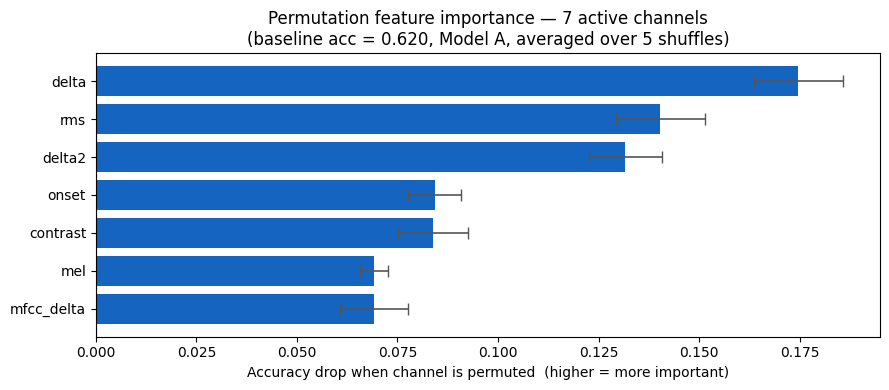

In [16]:
# === Permutation feature importance (channel-level, evaluated on Model A) ===
N_REPEATS = 5
rng = np.random.default_rng(SEED)
modelA = models[0]

def _eval_acc(X_input):
    modelA.eval()
    c = t = 0
    ds = DataLoader(
        TensorDataset(torch.from_numpy(X_input.astype("float32")),
                      torch.from_numpy(yte)),
        batch_size=64, shuffle=False
    )
    with torch.no_grad():
        for xb, yb in ds:
            c += (modelA(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
            t += len(yb)
    return c / t

baseline_acc = _eval_acc(Xte)
print(f"baseline acc : {baseline_acc:.4f}  (Model A)")
print(f"active channels ({N_CHAN_SEL}): {sel_names}\n")

importance_mean, importance_std = [], []
for ch, name in enumerate(sel_names):
    drops = []
    for _ in range(N_REPEATS):
        Xp = Xte.copy()
        idx = rng.permutation(len(Xp))
        Xp[:, ch, :, :] = Xp[idx, ch, :, :]
        drops.append(baseline_acc - _eval_acc(Xp))
    mean_d, std_d = float(np.mean(drops)), float(np.std(drops))
    importance_mean.append(mean_d)
    importance_std.append(std_d)
    print(f"  {name:<12}  drop = {mean_d:+.4f}  (\u00b1{std_d:.4f})")

order  = np.argsort(importance_mean)[::-1]
names  = [sel_names[i] for i in order]
means  = [importance_mean[i] for i in order]
stds   = [importance_std[i]  for i in order]
colors = ["#1565C0" if v >= 0 else "#C62828" for v in means]

fig, ax = plt.subplots(figsize=(9, max(4, N_CHAN_SEL * 0.5)))
ax.barh(names, means, xerr=stds, color=colors,
        error_kw=dict(ecolor="#555", capsize=4, lw=1.2))
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.invert_yaxis()
ax.set_xlabel("Accuracy drop when channel is permuted  (higher = more important)")
ax.set_title(
    f"Permutation feature importance — {N_CHAN_SEL} active channels\n"
    f"(baseline acc = {baseline_acc:.3f}, Model A, averaged over {N_REPEATS} shuffles)")
plt.tight_layout()
plt.show()

---
## 8 · Written analysis of results

**Final result: 0.629 ensemble test accuracy** (speaker-independent, 4-model ensemble A+B+C+D).

### What worked

- **Warm restarts (CosineAnnealingWarmRestarts, T_0=110).** The LR kick at ep120 consistently let models escape local minima and find better checkpoints in the second cycle. Best val for B (0.599) and D (0.593) were both post-restart. A restart grace that resets the early-stop counter at each T_0 boundary was essential — without it, members triggered premature stopping during the post-restart val dip.
- **7-channel feature set.** Permutation importance confirmed all 7 channels contribute meaningfully (drop ≥ +0.069). Adding voiced-masked f0/rolloff/bandwidth/centroid hurt — those channels are too sparse on a speaker-independent split and f0 had negative importance (-0.002).
- **Label smoothing 0.10 + AdamW weight_decay=1e-2.** Together these kept the train/val gap manageable (~0.22 at ep200 vs ~0.35 without).
- **Replacing D (fc=256, s7) with D (fc=128, s123).** The original D died at ep93 after the warm restart destabilised it. fc=128 members survive restarts reliably; the new D reached val 0.593.

### Where it struggles

- **Disgusted (F1 = 0.557) is the ceiling.** Acoustically similar to Angry (both high-arousal, negative-valence); RMS energy — the model's top feature — can't separate them. No architecture, loss, or regularisation change moved Disgusted significantly. This is a data problem: CREMA-D + RAVDESS don't have enough actor diversity for Disgusted.
- **Fearful and Happy (F1 ≈ 0.55–0.62)** are the next hardest — both share arousal cues with Angry.
- **CNN ceiling at ~0.629.** Multiple runs with different schedules, dropout levels, feature sets, and ensemble configs all converged to 0.629. The 7-channel hand-crafted features simply don't carry enough information to push further on a speaker-independent split.

### Failed experiments

- **SpecAugment** — ~5.9k training clips is too small; masking destroyed the subtle patterns needed for Neutral. Hurt by ~0.02.
- **Focal loss** — redundant with balanced class weights; hurt regularisation by forcing label_smoothing down.
- **Adding f0/rolloff/bandwidth/centroid** — voiced masking left these channels too sparse; permutation importance near-zero or negative on the speaker-independent split.
- **fc=256 + seed=7 ensemble member** — warm restart destabilised this combination every time.

### What's next

The feature ceiling is clear. WavLM-large (`wav2vec2f.ipynb`) operates directly on raw 16 kHz waveforms and learns representations we can't hand-engineer — breathiness, micro-pitch variation, voice quality — which are exactly the cues that separate Fearful/Disgusted/Happy at the margin.